# Causality

In [1]:
from datascience import *
import numpy as np

%matplotlib inline
import matplotlib.pyplot as plots
plots.style.use('fivethirtyeight')

import warnings
warnings.simplefilter("ignore")

## Review: Comparing Two Samples

In [2]:
def difference_of_means(table, numeric_label, group_label):
    """
    Takes: name of table, column label of numerical variable,
    column label of group-label variable
    
    Returns: Difference of means of the two groups
    """
    
    #table with the two relevant columns
    reduced = table.select(numeric_label, group_label)  
    
    # table containing group means
    means_table = reduced.group(group_label, np.average)
    
    # array of group means
    means = means_table.column(1)
    
    return means.item(1) - means.item(0)

In [3]:
def one_simulated_difference(table, numeric_label, group_label):
    """
    Takes: name of table, column label of numerical variable,
    column label of group-label variable
    
    Returns: Difference of means of the two groups after shuffling labels
    """
    
    # array of shuffled labels
    shuffled_labels = table.sample(
        with_replacement = False).column(group_label)
    
    # table of numerical variable and shuffled labels
    shuffled_table = table.select(numeric_label).with_column(
        'Shuffled Label', shuffled_labels)
    
    return difference_of_means(
        shuffled_table, numeric_label, 'Shuffled Label')   

In [4]:
births = Table.read_table('baby.csv')

In [5]:
means = births.group('Maternal Smoker', np.average)
means

Maternal Smoker,Birth Weight average,Gestational Days average,Maternal Age average,Maternal Height average,Maternal Pregnancy Weight average
False,123.085,279.874,27.5441,64.014,129.48
True,113.819,277.898,26.7364,64.1046,126.919


In [6]:
observed_difference = means.column(1).item(1) - means.column(1).item(0)
observed_difference

-9.266142572024918

In [7]:
one_simulated_difference(births, 'Birth Weight', 'Maternal Smoker')

-0.094071941130764

In [8]:
differences = make_array()

for i in np.arange(2000):
    new_difference = one_simulated_difference(births, 'Birth Weight', 'Maternal Smoker')
    differences = np.append(differences, new_difference)

Observed Difference: -9.266142572024918


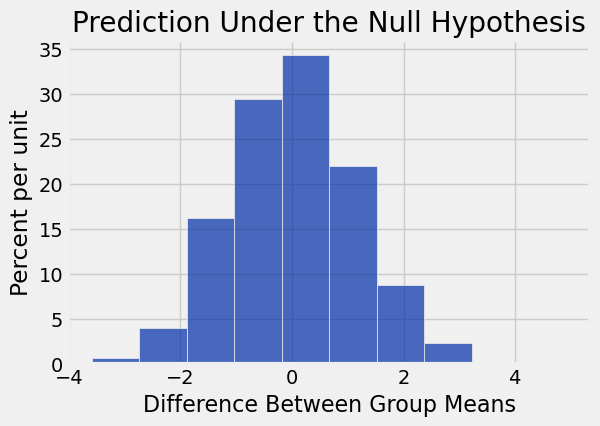

In [9]:
Table().with_column('Difference Between Group Means', differences).hist()
print('Observed Difference:', observed_difference)
plots.title('Prediction Under the Null Hypothesis');

## Randomized Control Experiment

In [10]:
botox = Table.read_table('bta.csv')
botox.show()

Group,Result
Control,1
Control,1
Control,0
Control,0
Control,0
Control,0
Control,0
Control,0
Control,0
Control,0


In [11]:
botox.pivot('Result', 'Group')

Group,0.0,1.0
Control,14,2
Treatment,6,9


In [12]:
botox.group('Group', np.average)

Group,Result average
Control,0.125
Treatment,0.6


## Testing the Hypothesis

In [13]:
observed_diff = difference_of_means(botox, 'Result', 'Group')
observed_diff

0.475

In [14]:
one_simulated_difference(botox, 'Result', 'Group')

-0.3

In [15]:
simulated_diffs = make_array()

for i in np.arange(10000):
    sim_diff = one_simulated_difference(botox, 'Result', 'Group')
    simulated_diffs = np.append(simulated_diffs, sim_diff)

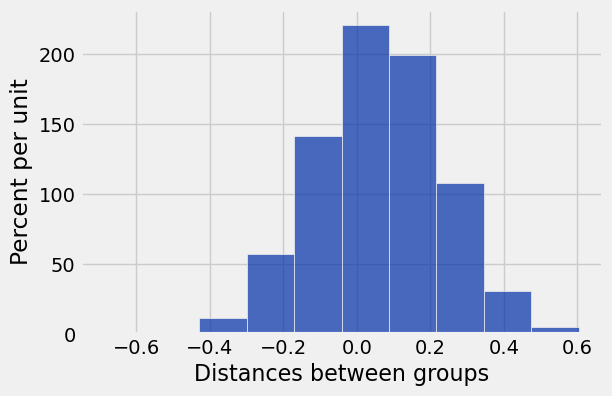

In [16]:
col_name = 'Distances between groups'
Table().with_column(col_name, simulated_diffs).hist(col_name)

In [17]:
# p-value
sum(simulated_diffs >= observed_diff)/len(simulated_diffs)

0.0063

## Discussion Question: Super Soda

In [18]:
def simulate_one_count(sample_size):
    return np.count_nonzero(np.random.choice(['H', 'T'], sample_size) == 'H')
simulate_one_count(200)

100

In [19]:
num_simulations = 10000
counts = make_array()
for i in np.arange(num_simulations):
    counts = np.append(counts, simulate_one_count(200))

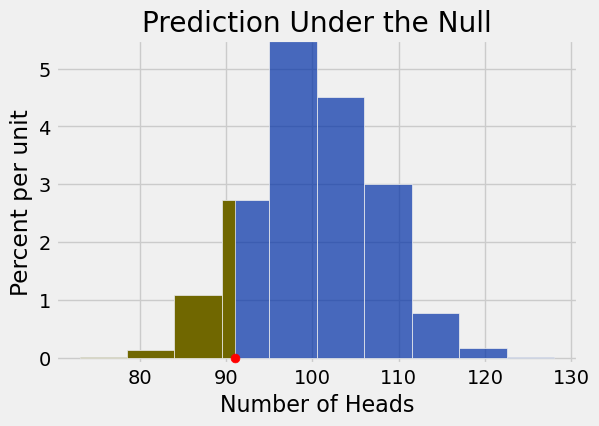

In [20]:
trials = Table().with_column('Number of Heads', counts)
trials.hist(right_end=91)
plots.ylim(-0.001, 0.055)
plots.scatter(91, 0, color='red', s=40, zorder=3)
plots.title('Prediction Under the Null');

In [21]:
np.count_nonzero(counts <= 91)/len(counts)

0.1117

Conclusion: 

## Changing the number of simulations

In [22]:
# Keeping the data fixed, we can re-run the test with a new simulation under the null
def run_test(num_simulations, sample_size):
    counts = make_array()
    for i in np.arange(num_simulations):
        counts = np.append(counts, simulate_one_count(sample_size))
    return counts

counts = run_test(10000, 200)
np.count_nonzero(counts <= 91)/len(counts)

0.1131

In [23]:
# Let's repeat that 50 times for each number of simulations
tests = Table(['simulations', 'p-value for 91'])
for num_sims in [100, 1000, 10000]:
    for k in np.arange(50):
        counts = run_test(num_sims, 200)
        tests = tests.with_row([
            num_sims, 
            np.count_nonzero(counts <= 91)/len(counts),
        ])
tests.show(3)

simulations,p-value for 91
100,0.04
100,0.14
100,0.12


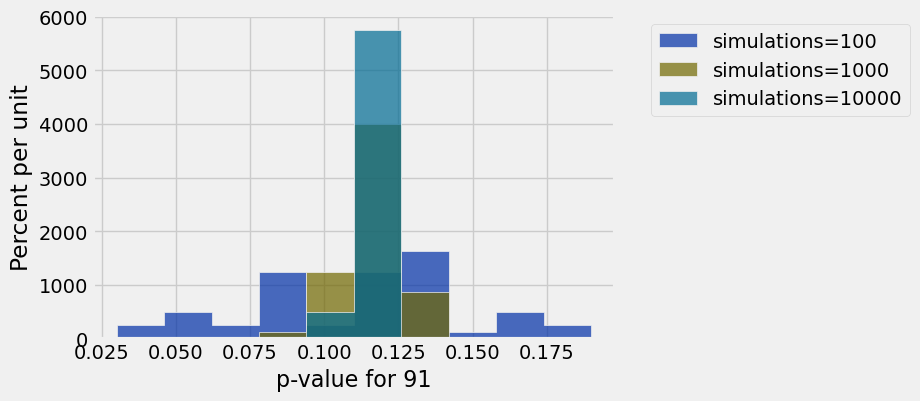

In [24]:
# For larger numbers of simulations, p-values are more consistent
tests.hist(1, group='simulations')

## Changing the size of the taste test

In [25]:
# Suppose that the true proportion of people who prefer Super Soda is 45%
true_proportion = 0.45
true_distribution = make_array(true_proportion, 1 - true_proportion)
true_distribution

array([ 0.45,  0.55])

In [26]:
# Taste tests with 200 people will give varioius numbers of people who prefer Super Soda
sample_size = 200
sample_proportions(sample_size, true_distribution) * sample_size

array([  77.,  123.])

In [27]:
# If you run a taste test for 200 people, what might you conclude?
def run_experiment(num_simulations, sample_size, true_proportion):
    # Collect data
    true_distribution = make_array(true_proportion, 1 - true_proportion)
    taste_test_results = sample_proportions(sample_size, true_distribution) * sample_size
    observed_stat_from_this_sample = taste_test_results.item(0)
    
    # Conduct hypothesis test
    counts = run_test(num_simulations, sample_size)
    p_value = np.count_nonzero(counts <= observed_stat_from_this_sample) / len(counts)
    return p_value

run_experiment(10000, 200, 0.45)

0.4702

Percent of p-values at or below 0.05: 40.0


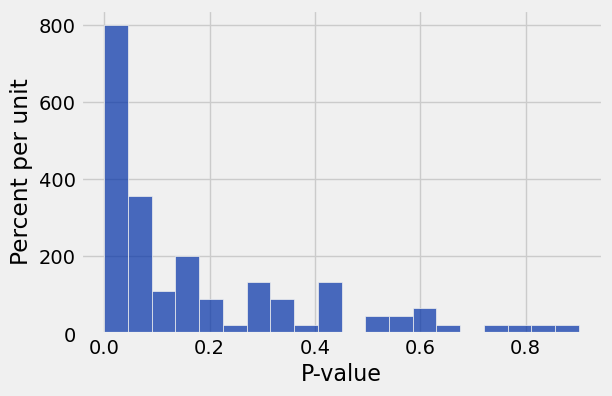

In [28]:
# Let's imagine running our taste test over and over again to see how often we reject the null
true_proportion = 0.45
sample_size = 200
p_values = make_array()
for k in np.arange(100):
    p_value = run_experiment(1000, sample_size, true_proportion)
    p_values = np.append(p_values, p_value)
Table().with_column('P-value', p_values).hist(0, bins=20)
print('Percent of p-values at or below 0.05:', 100 * np.count_nonzero(p_values <= 0.05) / len(p_values))